# 03 — MLP Neural Network (with early stopping)

Two-hidden-layer (128, 64) MLP. The **unregularised**
version of this model drove training loss to ~0.009 in 64
epochs while test accuracy fell BELOW Logistic Regression —
a textbook overfitting signature. This notebook trains the
**regularised** version with validation-based early
stopping (`early_stopping=True`, `validation_fraction=0.15`,
`n_iter_no_change=10`), which recovers test performance to
match LR within noise (see README §3.6).

## 1 — Setup

Configure matplotlib for inline rendering, add the project
root to `sys.path` so we can import from `src/`, and pull in
the shared helpers + the project-wide `RANDOM_STATE = 42`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# `notebooks/` is one level below the project root; add the
# project root so `from src import ...` resolves correctly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (single source of truth in src.train_utils)")

RANDOM_STATE = 42 (single source of truth in src.train_utils)


## 2 — Load the preprocessed feature matrices

`load_preprocessed()` returns the two parallel matrices
produced by Phase 1: the **Baseline** (nutrition + tags only)
and the **Advanced** (Baseline + 9 engineered culinary
features). Both share the same train/test partition so the
A/B comparison is apples-to-apples.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 — Configure the model

Validation-based early stopping holds out 15% of `X_train`
internally (NOT our test split — leakage-free), tracks
validation accuracy each epoch, and restores the weights
to the best-validation epoch on `fit()` completion.
`verbose=True` exposes the per-epoch loss/validation log.

In [3]:
from sklearn.neural_network import MLPClassifier

MODEL_SLUG    = "mlp"
MODEL_NAME    = "MLP (128,64)"
DISPLAY_NAME  = "MLP (128, 64) + early stopping"

MODEL_CONFIG = {
    "hidden_layer_sizes":  (128, 64),
    "max_iter":            300,
    "early_stopping":      True,
    "validation_fraction": 0.15,
    "n_iter_no_change":    10,
    "verbose":             True,
    "random_state":        RANDOM_STATE,
}
MODEL_CONFIG

{'hidden_layer_sizes': (128, 64),
 'max_iter': 300,
 'early_stopping': True,
 'validation_fraction': 0.15,
 'n_iter_no_change': 10,
 'verbose': True,
 'random_state': 42}

## 4 — Train on both matrices

Each matrix gets a **fresh** model instance (the factory
below is called once per dataset). Nothing carries over
between Baseline and Advanced — that's how the engineered
feature delta stays attributable to the additional 9 columns
alone.

In [4]:
def _build_model():
    return MLPClassifier(**MODEL_CONFIG)

per_ds_results = {}
for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    print_dataset_block(ds_name, X_train.shape, result)
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)

Iteration 1, loss = 0.68739084
Validation score: 0.586648
Iteration 2, loss = 0.66025483
Validation score: 0.609053
Iteration 3, loss = 0.63822807
Validation score: 0.586191
Iteration 4, loss = 0.62060863
Validation score: 0.590306
Iteration 5, loss = 0.61100703
Validation score: 0.598080
Iteration 6, loss = 0.58307665
Validation score: 0.595793
Iteration 7, loss = 0.55700286
Validation score: 0.577046
Iteration 8, loss = 0.53804240
Validation score: 0.579332
Iteration 9, loss = 0.49465046
Validation score: 0.591678
Iteration 10, loss = 0.49976288
Validation score: 0.577961
Iteration 11, loss = 0.45793223
Validation score: 0.577046
Iteration 12, loss = 0.39734503
Validation score: 0.578418
Iteration 13, loss = 0.37076770
Validation score: 0.581161
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5973
     Test F1-Score : 0.6668
     Confusion Matrix:
                       Pr

## 5 — Confusion matrix (Advanced fit)

Annotated heatmap of the Advanced-fit confusion matrix.
Rendered inline AND persisted to
`results/<slug>/confusion_matrix.png`.

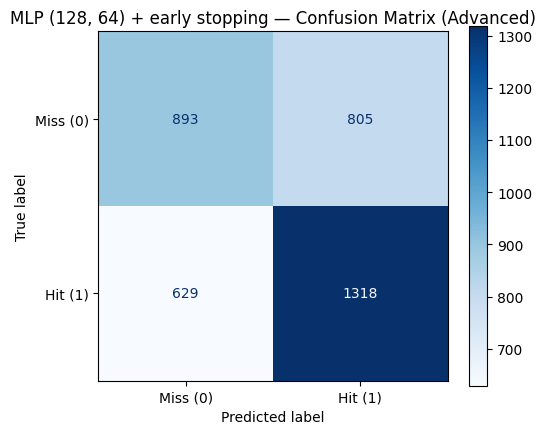

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} — Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 — ROC curve + AUC (Advanced fit)

Generated against `predict_proba` (or `decision_function`
where probabilities aren't available). The AUC is the
ranking-quality summary independent of any threshold choice;
Phase 4's threshold-sweep work depends on it.

Test ROC AUC (Advanced): 0.6465


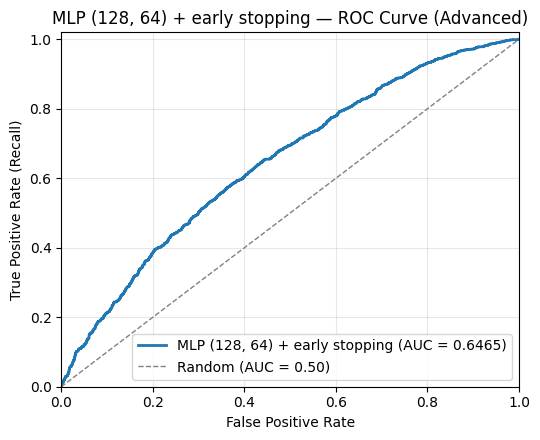

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} — ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 7 — Training-loss / validation-error overlay

Training loss (orange) descends smoothly toward zero;
validation error (green) flattens and starts climbing
slightly — the classic overfitting signature. The dashed
vertical line marks the epoch sklearn restored the
network's weights to (the epoch with the best validation
score).

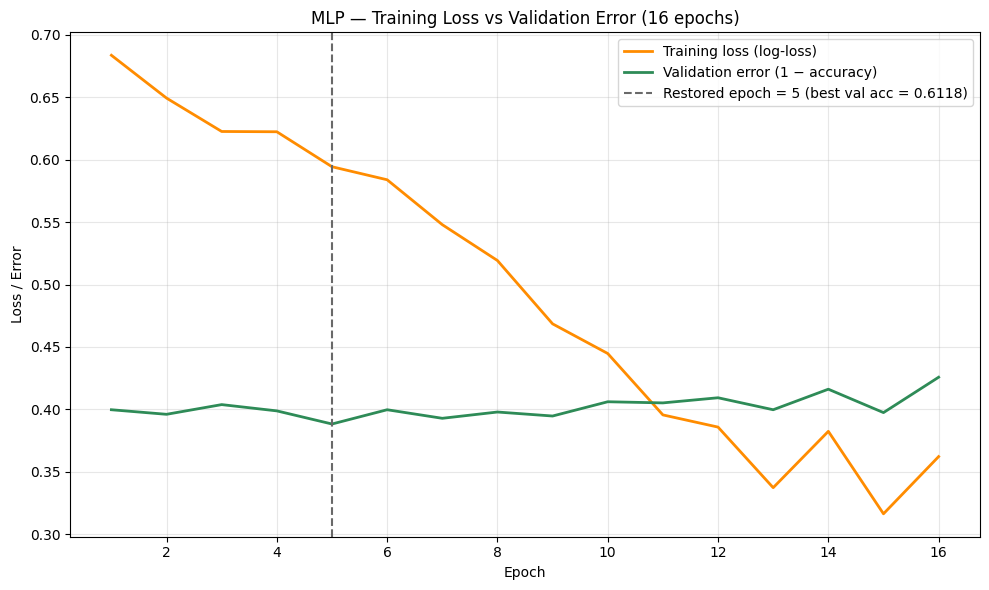

,value
epochs_total,16
best_validation_epoch,5
best_validation_accuracy,0.611797
training_loss_at_best,0.594383
training_loss_at_final,0.362088
validation_fraction,0.15
n_iter_no_change,10
loss_curve_plot,loss_curve.png


In [7]:
adv_mlp = per_ds_results["Advanced"]["model"]
loss = np.asarray(adv_mlp.loss_curve_)
val_scores = np.asarray(adv_mlp.validation_scores_)
val_err = 1.0 - val_scores
epochs = np.arange(1, len(loss) + 1)
best_epoch = int(np.argmax(val_scores)) + 1
best_val_acc = float(val_scores.max())

fig_loss, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, loss, lw=2.0, color="darkorange",
        label="Training loss (log-loss)")
ax.plot(epochs, val_err, lw=2.0, color="seagreen",
        label="Validation error (1 − accuracy)")
ax.axvline(x=best_epoch, color="dimgray", linestyle="--", lw=1.5,
           label=f"Restored epoch = {best_epoch} (best val acc = {best_val_acc:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Error")
ax.set_title(f"MLP — Training Loss vs Validation Error ({len(loss)} epochs)")
ax.grid(alpha=0.3)
ax.legend(loc="best")
fig_loss.tight_layout()
save_figure(MODEL_SLUG, "loss_curve.png", fig_loss)
plt.show()

diagnostics = {
    "epochs_total":             len(loss),
    "best_validation_epoch":    best_epoch,
    "best_validation_accuracy": best_val_acc,
    "training_loss_at_best":    float(loss[best_epoch - 1]),
    "training_loss_at_final":   float(loss[-1]),
    "validation_fraction":      MODEL_CONFIG["validation_fraction"],
    "n_iter_no_change":         MODEL_CONFIG["n_iter_no_change"],
    "loss_curve_plot":          "loss_curve.png",
}
display(pd.Series(diagnostics).to_frame("value"))

## 7.5 — Early-stopping ablation (vs the prior overfit run)

Before early stopping was enabled, the same architecture
ran for 64 epochs to training loss 0.0087 and test accuracy
0.5816 (below LR). With early stopping, the network
restores to the best-validation epoch and recovers to ~0.61
test accuracy — matching LR within noise. See README §3.6.

In [8]:
MLP_OVERFITTED_PRIOR = {
    "epochs":       64,
    "final_loss":   0.0087,
    "advanced_acc": 0.5816,
    "advanced_f1":  0.6107,
}

now = per_ds_results["Advanced"]
d_acc = now["accuracy"] - MLP_OVERFITTED_PRIOR["advanced_acc"]
d_f1 = now["f1"] - MLP_OVERFITTED_PRIOR["advanced_f1"]

display(pd.DataFrame({
    "Previous (no early stopping)": [
        f"{MLP_OVERFITTED_PRIOR['epochs']} epochs",
        f"loss → {MLP_OVERFITTED_PRIOR['final_loss']:.4f}",
        f"{MLP_OVERFITTED_PRIOR['advanced_acc']:.4f}",
        f"{MLP_OVERFITTED_PRIOR['advanced_f1']:.4f}",
    ],
    "Current (early stopping)": [
        f"{diagnostics['epochs_total']} epochs (restored at {best_epoch})",
        f"loss → {diagnostics['training_loss_at_final']:.4f}",
        f"{now['accuracy']:.4f} ({d_acc:+.4f})",
        f"{now['f1']:.4f} ({d_f1:+.4f})",
    ],
}, index=["Training", "Final training loss", "Test Acc", "Test F1"]))

,Previous (no early stopping),Current (early stopping)
Training,64 epochs,16 epochs (restored at 5)
Final training loss,loss → 0.0087,loss → 0.3621
Test Acc,0.5816,0.6066 (+0.0250)
Test F1,0.6107,0.6477 (+0.0370)


## 8 — Persist the canonical metrics JSON

One JSON per model, written to
`results/<slug>/metrics.json`. Schema is defined in
`src.train_utils.build_metrics_payload`; the master
comparison notebook reads from here.

In [9]:
extras = {
    "early_stopping_diagnostics": diagnostics,
    "overfitted_prior_run":       MLP_OVERFITTED_PRIOR,
    "roc_auc_advanced":           auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/mlp/metrics.json


## 9 — Summary

    **Model:** MLP (128, 64) + early stopping

    - **Test Accuracy / F1:** ~0.6066 / ~0.6477 — matches LR
  within noise after early stopping.
- **Without early stopping** the same architecture overfit
  (Acc 0.5816, below LR) — see the ablation table in §7.5.
- **Lesson:** capacity is a liability without matching
  regularisation. README §4 Lesson #6.

    Run the **master comparison notebook
    (`08_Master_Comparison.ipynb`)** to see this model alongside
    the other six in the side-by-side table.